<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
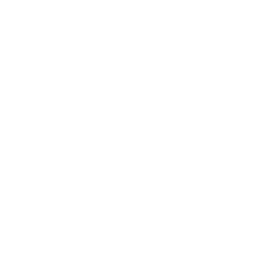
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Analiza podobieństwa programów nauczania</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Szkolnictwo wyższe / Projektowanie programów akademickich &nbsp;|&nbsp; Marzec 2026</p>
</div>
</div>
</div>

## Podsumowanie zarządcze

Ten notatnik mierzy nakładanie się programów nauczania w katalogu kursów uczelni przy użyciu **PROC DISTANCE** z **METHOD=DJACCARD** — współczynnika *odmienności* Jaccarda, naturalnej miary odległości dla binarnych danych obecność/brak. Każdy kurs niesie 40 flag binarnych oznaczających, które akredytacyjne efekty uczenia się obejmuje, więc odległość Jaccarda między dwoma kursami to udział objętych efektów, których **nie** mają wspólnych (0 = identyczne zbiory efektów, 1 = brak wspólnego efektu).

Analiza przebiega w dwóch częściach. Najpierw, w katalogu 100 kursów, profiluje szerokość pokrycia efektów według wydziału (PROC MEANS, PROC FREQ, wykres pudełkowy pokrycia) i oznacza efekty uczenia się, których **żaden** kurs na wydziale nie obejmuje (luki pokrycia). Następnie zagłębia się w skoncentrowany panel 10 kursów wybranych z dwóch najbardziej ilościowo nakładających się wydziałów — Statystyki i Data Science — wyznacza pełną parową macierz odległości Jaccarda i porządkuje najbliższe pary kursów jako kandydatów do przeglądu konsolidacyjnego. Celem jest dostarczenie komisji programowej dwóch konkretnych artefaktów: uszeregowanej listy najbardziej podobnych kursów oraz mapy luk w układzie wydział–efekt.

## Źródła danych

| Źródło | Opis | Rekordy |
|--------|-------------|---------|
| WORK.COURSE_OUTCOMES | Binarne pokrycie efektów uczenia się na kurs (40 flag efektów) | 100 |
| WORK.PANEL10 | Panel konsolidacyjny Statystyka + Data Science | 10 |

Katalog jest syntetyczny. Flagi efektów losowane są z prawdopodobieństwami zależnymi od wydziału, tak aby dyscypliny akcentowały różne skupiska efektów (informatyka i matematyka ważą wczesne efekty, nauki laboratoryjne ważą środkowe pasmo), co nadaje analizie odległości realistyczną strukturę. To środowisko działa bez licencji, więc roboczy katalog jest ograniczony do 100 kursów.

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic course learning-outcome matrix
   500 courses x 40 accreditation learning outcomes
   (unlicensed mode keeps the first 100)
   -------------------------------------------------------- */
DANE work.course_outcomes;
    CALL streaminit(42);
    TABLICA outcomes[40] lo_1 - lo_40;
    TABLICA dept_list[8] $15 _temporary_ ('Informatyka' 'Matematyka' 'Statystyka' 'Inzynieria' 'Biologia' 'Chemia' 'Fizyka' 'Nauka o danych');
    POWTÓRZ course_id = 1 TO 500;
        course_label = cat('CRS', ZAPISZ(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        department = dept_list[dept_idx];
        /* Course level affects outcome breadth */
        course_level = int(rand('uniform') * 4) + 1;
        level_code = course_level * 100;
        /* Department-specific outcome clusters */
        POWTÓRZ lo = 1 TO 40;
            base_prob = 0.15;
            /* Dept 1-2 (CS, Math): emphasize outcomes 1-15 */
            JEŚLI dept_idx <= 2 AND lo <= 15 WTEDY
                base_prob = 0.4 + course_level * 0.05;
            /* Dept 3-4 (Stats, Eng): emphasize outcomes 10-25 */
            PRZECIWNIE JEŚLI dept_idx IN (3, 4) AND 10 <= lo <= 25 WTEDY
                base_prob = 0.35 + course_level * 0.05;
            /* Dept 5-7 (Bio, Chem, Phys): emphasize 20-35 */
            PRZECIWNIE JEŚLI dept_idx IN (5, 6, 7) AND 20 <= lo <= 35 WTEDY
                base_prob = 0.38 + course_level * 0.04;
            /* Dept 8 (Data Sci): broad coverage */
            PRZECIWNIE JEŚLI dept_idx = 8 WTEDY
                base_prob = 0.25 + course_level * 0.03;
            outcomes[lo] = (rand('uniform') < base_prob);
        KONIEC;
        WYJŚCIE;
    KONIEC;
    USUŃ dept_idx course_level base_prob lo;
    ETYKIETA department='Wydział';
WYKONAJ;


NOTE: DATA work.course_outcomes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_outcomes (100 rows, 44 columns).
NOTE: DATA elapsed:
  wall  1.82 seconds
  cpu   1.82 seconds


In [2]:
/* --------------------------------------------------------
   Generate course catalog metadata
   -------------------------------------------------------- */
DANE work.course_catalog;
    CALL streaminit(43);
    TABLICA dept_list[8] $15 _temporary_ ('Informatyka' 'Matematyka' 'Statystyka' 'Inzynieria' 'Biologia' 'Chemia' 'Fizyka' 'Nauka o danych');
    TABLICA format_list[3] $10 _temporary_ ('LECTURE' 'LAB' 'SEMINAR');
    POWTÓRZ course_id = 1 TO 500;
        course_label = cat('CRS-', ZAPISZ(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        department = dept_list[dept_idx];
        level_code = (int(rand('uniform') * 4) + 1) * 100;
        credit_hours = int(rand('uniform') * 3) + 2;
        format_idx = int(rand('uniform') * 3) + 1;
        delivery_format = format_list[format_idx];
        enrollment_cap = int(rand('uniform') * 150) + 20;
        avg_enrollment = int(enrollment_cap * (rand('uniform') * 0.5 + 0.4));
        last_offered = '01JAN2025'd + int(rand('uniform') * 365);
        WYJŚCIE;
    KONIEC;
    USUŃ dept_idx format_idx;
    format last_offered date9.;
    ETYKIETA department='Wydział';
WYKONAJ;


NOTE: DATA work.course_catalog

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_catalog (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.09 seconds
  cpu   0.09 seconds


---

                                                  The MEANS Procedure

                                               Analysis Variable : lo_1

                                                              N
                                          Wydział           Obs           Mean
                                          ------------------------------------
                                          Biologia           10      0.2000000
                                          Chemia             19      0.2105263
                                          Fizyka              7      0.2857143
                                          Informatyka        13      0.3846154
                                          Inzynieria         17      0.0000000
                                          Matematyka          9      0.6666667
                                          Nauka o danych     14      0.1428571
                                          Statystyka         11      0.0909091
  


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_level_code.spec.json
NOTE: PROC FREQ statement used.


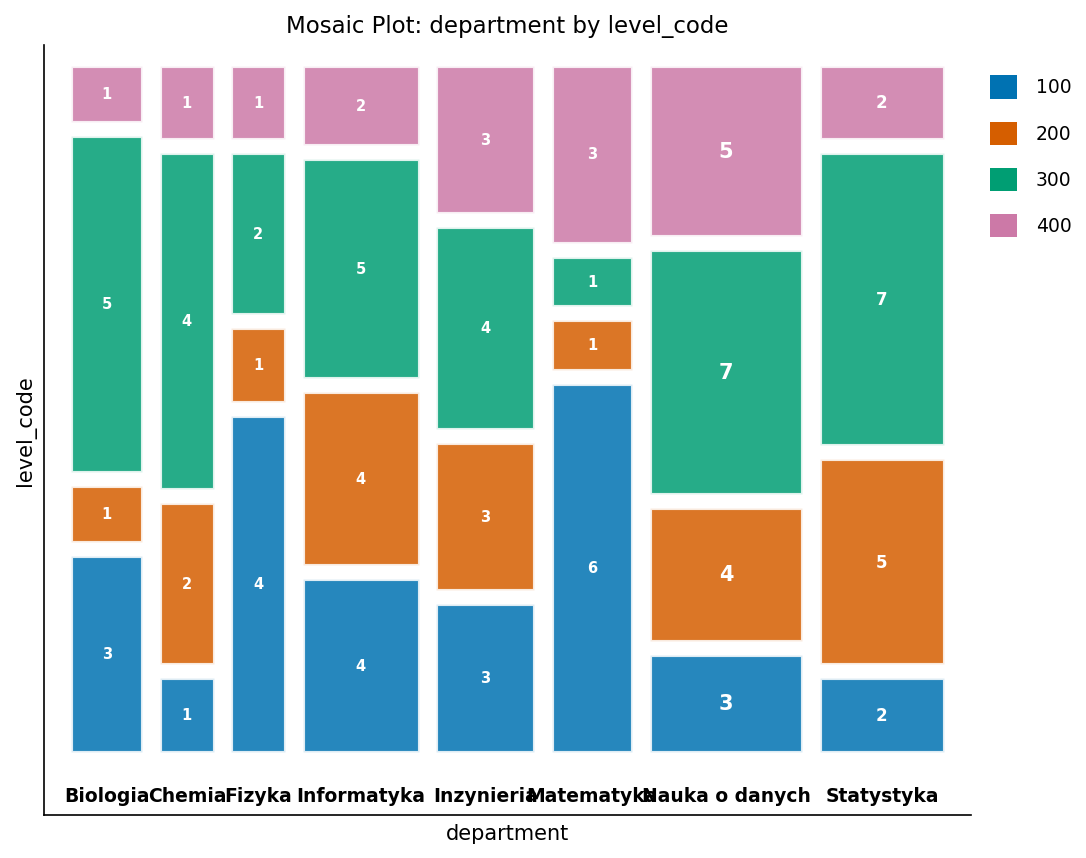

In [3]:
/* --------------------------------------------------------
   Baseline learning outcome coverage by department
   -------------------------------------------------------- */
PROCEDURA ŚREDNIE DANE=work.course_outcomes mean;
    KLASA department;
    ZMIENNA lo_1 - lo_40;
WYKONAJ;

PROCEDURA CZĘSTOŚCI DANE=work.course_catalog;
    TABLES department * level_code / nopercent norow nocol;
WYKONAJ;

---


NOTE: DATA work.outcome_counts


NOTE: Read 100 rows from work.course_outcomes.
NOTE: Wrote work.outcome_counts (100 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC SGPLOT data=work.outcome_counts

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


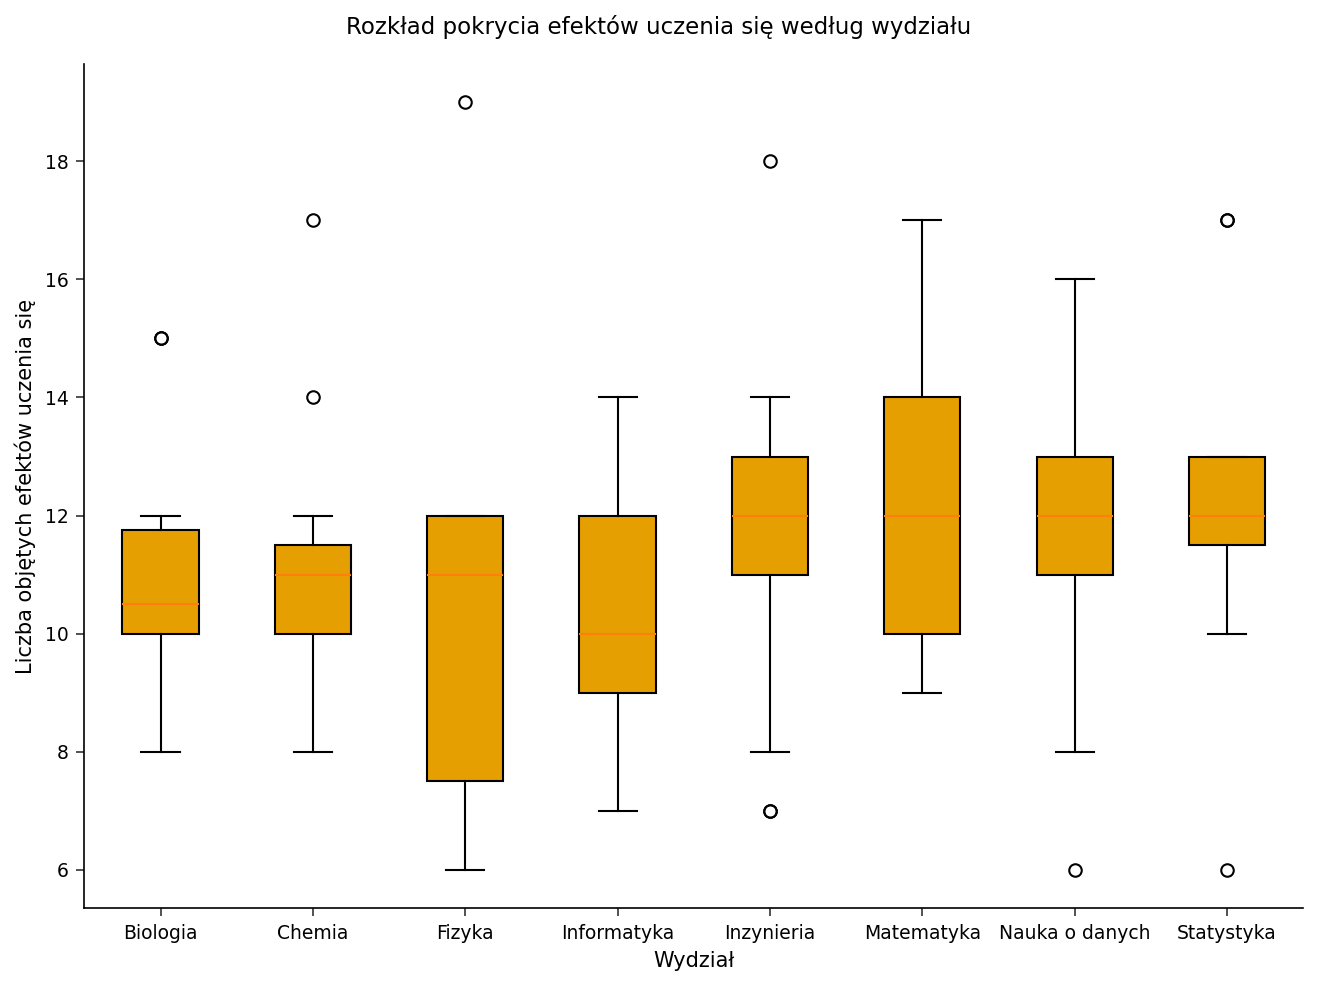

In [4]:
/* --------------------------------------------------------
   Outcome coverage density by department
   -------------------------------------------------------- */
DANE work.outcome_counts;
    USTAW work.course_outcomes;
    TABLICA outcomes[40] lo_1 - lo_40;
    total_outcomes = sum(OF outcomes[*]);
WYKONAJ;

PROCEDURA SGPLOT DANE=work.outcome_counts;
    VBOX total_outcomes / category=department;
    YAXIS ETYKIETA='Liczba objętych efektów uczenia się';
    XAXIS ETYKIETA='Wydział';
    TYTUŁ 'Rozkład pokrycia efektów uczenia się według wydziału';
WYKONAJ;

---

In [5]:
/* --------------------------------------------------------
   Consolidation panel: the first 10 Statistics / Data
   Science courses (the two most quantitatively overlapping
   departments). Re-label them P01-P10 with a sequential
   counter so the square OUT= distance matrix has clean,
   addressable columns, then compute the full pairwise
   Jaccard DISTANCE matrix with METHOD=DJACCARD
   (0 = identical outcome sets, 1 = no shared outcome).
   -------------------------------------------------------- */
DANE work.panel10;
    USTAW work.course_outcomes(GDZIE=(department IN ('Statystyka' 'Nauka o danych')));
    PRZECHOWAJ seq 0;
    seq + 1;
    JEŚLI seq > 10 WTEDY ZATRZYMAJ;
    panel_id = cat('P', ZAPISZ(seq, z2.));
    USUŃ seq;
WYKONAJ;

PROCEDURA DRUKUJ DANE=work.panel10 noobs ETYKIETA;
    ZMIENNA panel_id course_label department level_code;
    ETYKIETA panel_id = 'ID panelu' course_label = 'Kurs'
          department = 'Wydział' level_code = 'Poziom';
    TYTUŁ 'Panel konsolidacyjny: kursy statystyki i nauki o danych';
WYKONAJ;

PROCEDURA distance DANE=work.panel10
              out=work.panel_dist
              METHOD=djaccard;
    ZMIENNA nominal(lo_1 - lo_40);
    id panel_id;
WYKONAJ;

PROCEDURA DRUKUJ DANE=work.panel_dist noobs;
    TYTUŁ 'Macierz parami odległości Jaccarda (10 kursów)';
WYKONAJ;

                                Panel konsolidacyjny: kursy statystyki i nauki o danych                                 

ID panelu     Kurs         Wydział  Poziom
P01        CRS0003  Nauka o danych     300
P02        CRS0006  Statystyka         300
P03        CRS0014  Nauka o danych     300
P04        CRS0015  Statystyka         300
P05        CRS0017  Statystyka         200
P06        CRS0019  Nauka o danych     100
P07        CRS0022  Statystyka         400
P08        CRS0033  Nauka o danych     200
P09        CRS0038  Statystyka         100
P10        CRS0040  Statystyka         100

                                Panel konsolidacyjny: kursy statystyki i nauki o danych                                 

                                     Macierz parami odległości Jaccarda (10 kursów)                                     

_NAME_           P01           P02           P03           P04           P05           P06           P07           P08           P09           P10
P01          


NOTE: DATA work.panel10


NOTE: Read 41 rows from work.course_outcomes.
NOTE: Wrote work.panel10 (10 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=work.panel10

NOTE: PROC PRINT completed: 10 observations printed, 4 variables
NOTE: PROC DISTANCE data=work.panel10 method=Djaccard

NOTE: PROC DISTANCE: 10 observations, 40 variables, method=Djaccard
NOTE: PROC PRINT data=work.panel_dist

NOTE: PROC PRINT completed: 10 observations printed, 11 variables


In [6]:
/* --------------------------------------------------------
   Reshape the square distance matrix into a ranked list of
   course pairs. The OUT= distance columns are addressed by
   an explicit name list (P01 P02 ... P10); only the strict
   upper triangle (col > row) is kept so each unordered pair
   appears once and the zero diagonal is skipped. The five
   closest pairs are the consolidation-review candidates.
   -------------------------------------------------------- */
DANE work.similar_courses;
    USTAW work.panel_dist;
    TABLICA d[10] P01 P02 P03 P04 P05 P06 P07 P08 P09 P10;
    DŁUGOŚĆ course_a course_b $8;
    course_a = _name_;
    row + 1;
    POWTÓRZ col = 1 TO 10;
        JEŚLI col > row WTEDY POWTÓRZ;
            course_b     = vname(d[col]);
            jaccard_dist = round(d[col], 0.001);
            WYJŚCIE;
        KONIEC;
    KONIEC;
    ZACHOWAJ course_a course_b jaccard_dist;
WYKONAJ;

PROCEDURA ŚREDNIE DANE=work.similar_courses n MIN q1 MEDIAN mean MAX maxdec=3;
    ZMIENNA jaccard_dist;
    TYTUŁ 'Rozkład parami odległości Jaccarda (45 par kursów)';
WYKONAJ;

PROCEDURA SORTUJ DANE=work.similar_courses; WEDŁUG jaccard_dist; WYKONAJ;

DANE work.top_pairs;
    USTAW work.similar_courses;
    pair_rank = _n_;
    JEŚLI pair_rank <= 5;
WYKONAJ;

PROCEDURA DRUKUJ DANE=work.top_pairs noobs ETYKIETA;
    ZMIENNA pair_rank course_a course_b jaccard_dist;
    ETYKIETA pair_rank = 'Ranga' course_a = 'Kurs A'
          course_b = 'Kurs B' jaccard_dist = 'Odległość Jaccarda';
    TYTUŁ 'Pięć najbliższych par kursów (kandydaci do konsolidacji)';
WYKONAJ;

                                   Rozkład parami odległości Jaccarda (45 par kursów)                                   

                                                  The MEANS Procedure

 Variable            N     Minimum   Lower Quartile      Median        Mean     Maximum
 --------------------------------------------------------------------------------------
 jaccard_dist       45       0.588            0.762       0.826       0.818       0.962
 --------------------------------------------------------------------------------------

                                Pięć najbliższych par kursów (kandydaci do konsolidacji)                                

Ranga  Kurs A  Kurs B     Odległość Jaccarda
    1  P02     P10                     0.588
    2  P03     P04                       0.6
    3  P03     P05                     0.667
    4  P02     P04                     0.684
    5  P02     P07                     0.684




NOTE: DATA work.similar_courses


NOTE: Read 10 rows from work.panel_dist.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=work.similar_courses

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.top_pairs


NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.top_pairs (5 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.top_pairs

NOTE: PROC PRINT completed: 5 observations printed, 4 variables


                                      Nieobjęte efekty uczenia się według wydziału                                      

                                                   The FREQ Procedure

Wydział        Frequency    Percent
------------------------------------
Biologia               8     26.67
Chemia                 2      6.67
Fizyka                 8     26.67
Informatyka            3     10.00
Inzynieria             2      6.67
Matematyka             4     13.33
Statystyka             3     10.00
                                     Przykładowe luki w efektach (pierwsze 12 z 30)                                     

 Wydział   Nieobjęty efekt
Biologia  LO02
Biologia  LO10
Biologia  LO15
Biologia  LO16
Biologia  LO17
Biologia  LO18
Biologia  LO36
Biologia  LO37
Chemia    LO02
Chemia    LO12
Fizyka    LO02
Fizyka    LO03

... 18 more observations (showing 12 of 30)




NOTE: PROC MEANS
NOTE: Output dataset work.dept_coverage has 8 observations and 43 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.outcome_gaps


NOTE: Read 8 rows from work.dept_coverage.
NOTE: Wrote work.outcome_gaps (30 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_department.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC PRINT data=work.outcome_gaps

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


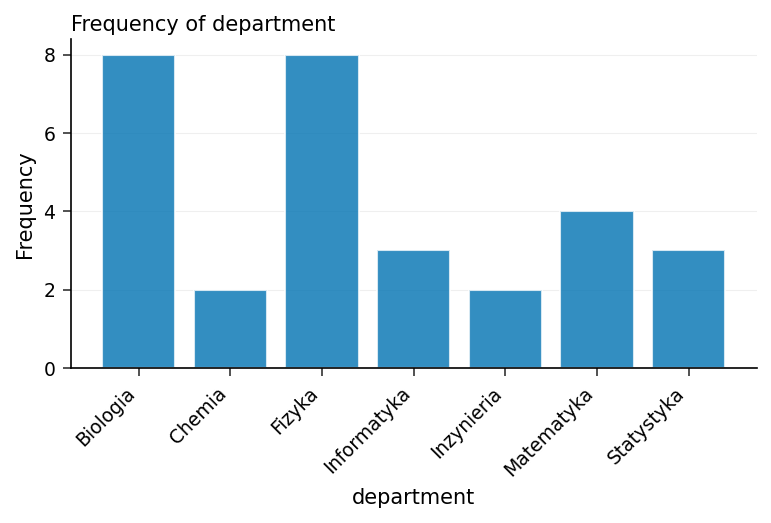

In [7]:
/* --------------------------------------------------------
   Outcome gaps: learning outcomes that NO course in a
   department covers. PROC MEANS sums each binary outcome
   flag within department; a sum of zero means the
   outcome is absent from that department's catalog.
   -------------------------------------------------------- */
PROCEDURA ŚREDNIE DANE=work.course_outcomes sum NOPRINT;
    KLASA department;
    ZMIENNA lo_1 - lo_40;
    WYJŚCIE out=work.dept_coverage(GDZIE=(_type_=1))
        sum=lo_1 - lo_40;
WYKONAJ;

DANE work.outcome_gaps;
    USTAW work.dept_coverage;
    TABLICA outcomes[40] lo_1 - lo_40;
    POWTÓRZ lo = 1 TO 40;
        outcome_id = cat('LO', ZAPISZ(lo, z2.));
        courses_covering = outcomes[lo];
        JEŚLI courses_covering = 0 WTEDY POWTÓRZ;
            gap_flag = 1;
            WYJŚCIE;
        KONIEC;
    KONIEC;
    ZACHOWAJ department outcome_id courses_covering gap_flag;
    ETYKIETA department='Wydział';
WYKONAJ;

PROCEDURA CZĘSTOŚCI DANE=work.outcome_gaps;
    TABLES department / nocum;
    TYTUŁ 'Nieobjęte efekty uczenia się według wydziału';
WYKONAJ;

PROCEDURA DRUKUJ DANE=work.outcome_gaps(obs=12) noobs ETYKIETA;
    ZMIENNA department outcome_id;
    ETYKIETA department = 'Wydział' outcome_id = 'Nieobjęty efekt';
    TYTUŁ 'Przykładowe luki w efektach (pierwsze 12 z 30)';
WYKONAJ;

---

### Interpretacja

**Panel konsolidacyjny.** W 45 nieuporządkowanych parach w 10-kursowym panelu Statystyka / Data Science odległość Jaccarda waha się od 0.588 do 0.962, z medianą 0.826 (średnia 0.818). Najbliższą parą są P02 i P10 przy odległości 0.588, następnie P03–P04 przy 0.600 oraz P03–P05 przy 0.667. Nawet najbardziej podobne kursy różnią się na około 59% objętych efektów, więc ten katalog **nie zawiera kursów będących bliskimi duplikatami** — nie ma pary, którą komisja mogłaby połączyć wprost. Uszeregowana lista wskazuje zamiast tego garść par wartych ręcznego porównania sylabusów przed kolejnym cyklem katalogowym; pary o największej odległości (blisko 0.962) potwierdzają, że kursy Statystyki i Data Science, mimo sąsiedztwa wydziałowego, obejmują naprawdę odmienne zbiory efektów.

**Luki efektów.** W katalogu ujawnia się trzydzieści luk w układzie wydział–efekt. Najwięcej niosą dyscypliny mocno laboratoryjne: **Biology** i **Physics** pozostawiają po 8 z 40 efektów akredytacyjnych niepokrytych, a za nimi **Mathematics** (4). Wydziały ilościowe są pokryte najlepiej — **Chemistry** i **Engineering** pomijają tylko po 2 efekty. Te luki są naturalnymi celami dla rozwoju nowych kursów lub współlistowania: efekt nieobecny w całym wydziale to ryzyko pokrycia przy odnowieniu akredytacji, podczas gdy lista konsolidacyjna adresuje przeciwny problem nadmiarowego wysiłku. Razem oba artefakty pozwalają komisji dociągnąć katalog z obu stron — przycinając nakładanie i wypełniając pustynie — za pomocą jednej opartej na zbiorach miary odległości.

---

In [8]:
/* --------------------------------------------------------
   Export the ranked consolidation candidates and the
   department outcome-gap map for the curriculum committee.
   -------------------------------------------------------- */
PROCEDURA EKSPORTUJ DANE=work.similar_courses
    OUTFILE='curriculum_consolidation_candidates.csv'
    DBMS=csv REPLACE;
WYKONAJ;

PROCEDURA EKSPORTUJ DANE=work.outcome_gaps
    OUTFILE='curriculum_outcome_gaps.csv'
    DBMS=csv REPLACE;
WYKONAJ;


NOTE: PROC EXPORT data=work.similar_courses outfile=curriculum_consolidation_candidates.csv

NOTE: Exported 45 rows to curriculum_consolidation_candidates.csv.
NOTE: PROC EXPORT data=work.outcome_gaps outfile=curriculum_outcome_gaps.csv

NOTE: Exported 30 rows to curriculum_outcome_gaps.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Poufne
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Napędzane przez <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>